C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7742222222222223

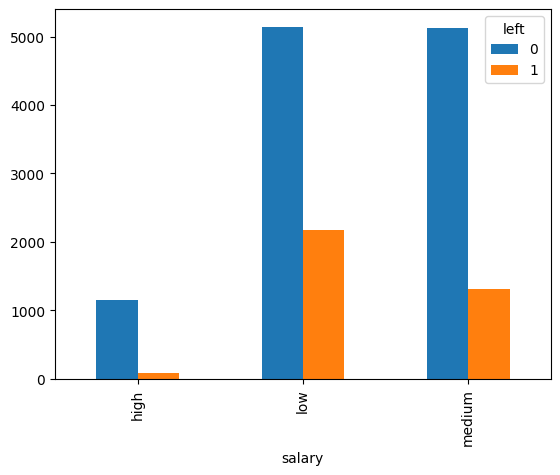

In [ ]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import axis
import matplotlib.pyplot as  plt

df = pd.read_csv("HR_comma_sep.csv")

left = df[df["left"] == 1]

retained = df[df["left"] == 0]
pd.crosstab(df.salary, df.left).plot(kind = "bar")

subdf = df[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
# print(subdf)

get_dummies = pd.get_dummies(subdf.salary, prefix = "salary").astype(int)

df_with_dummy = pd.concat([subdf,get_dummies],axis = "columns")

df_with_dummy.drop('salary', axis = 'columns',inplace = True)

x = df_with_dummy
y = df.left

from sklearn.model_selection import train_test_split

x_train,x_test ,y_train,y_test = train_test_split(
    x,
    y,
    train_size = 0.7
)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
model.predict(x_test)
model.score(x_test,y_test)